## Libraries

In [1]:
!pip install -q \
  datasets \
  transformers \
  peft \
  huggingface_hub \
  ipywidgets

!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [12]:
import os
import sys
import time
import torch
import random
import ipywidgets
from torch.utils.data import Dataset
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from itertools import islice
from huggingface_hub import login, HfFolder, HfApi, hf_hub_download, delete_repo, list_repo_files, snapshot_download
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, BitsAndBytesConfig
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:32" # Allows to split memory into pieces when allocating (normally the GPU VRAM needs a contiguous block of memory). Caps memory block size to maximum of 32 MB

## Load model & dataset

##### Login to huggingface

In [3]:
login()

#### Load base model

The GPU VRAM is not sufficient for training the model. We use LoRA to make it more efficient

In [ ]:
# Use only for loading new tinyllama model

"""

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")

# Load model with 8-bit quantization
model = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    load_in_8bit=True,               # 8-bit quantization
    device_map="auto"                # Automatically place layers on GPU/CPU
)

# Define LoRA configuration
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

# Apply LoRA to the quantized model
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

"""

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023


#### Load fine-tuned model with LoRA adapters

In [4]:
# Load base model
base = AutoModelForCausalLM.from_pretrained(
    "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    load_in_8bit=True,        # 8-bit quantization
    device_map="auto"
)

# Load your previously trained LoRA adapter (set as trainable)
model = PeftModel.from_pretrained(
    base,
    "eduhuemar001/tinyllama-german",
    is_trainable=True         # Required for continued training
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")

model.print_trainable_parameters()  # Only LoRA layers should be trainable
print(model.base_model_prefix)
print(model)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023
model
PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear8bitLt(
                (base_layer): Linear8bitLt(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
           

#### Load dataset

In [5]:
# Seed with a truly random int so the stream starts at a different offset every run
random.seed()
skip_count = random.randint(0, 1_000_000)

streamed_dataset = load_dataset(
    "wikipedia",
    "20220301.de",
    split="train",
    streaming=True,
    trust_remote_code=True
)

# Skip ahead to a random position in the stream
streamed_dataset = islice(streamed_dataset, skip_count, skip_count + 500)
dataset = list(streamed_dataset)

total_size = sum(len(item["text"].encode("utf-8")) for item in dataset)
print(f"Approximate true size: {total_size / 1024**2:.2f} MB")

README.md:   0%|          | 0.00/16.0k [00:00<?, ?B/s]

wikipedia.py:   0%|          | 0.00/36.7k [00:00<?, ?B/s]

Approximate true size: 1.45 MB


## Preprocessing

#### Tokenize data

Each subword is being converted to a token with a byte pair encoder

In [6]:
tokens = []

for item in dataset:
    ids = tokenizer(item["text"], return_attention_mask=False, add_special_tokens=False).input_ids
    tokens.extend(ids + [tokenizer.eos_token_id])  # optional: add EOS after each article

Token indices sequence length is longer than the specified maximum sequence length for this model (2288 > 2048). Running this sequence through the model will result in indexing errors


#### Split tokens into chunks



Documents with a high amount of tokens exceed the maximum context window of 2048 tokens. The documents are split up into chunks of 128 tokens.

In [7]:
block_size = 128
total_length = len(tokens) - (len(tokens) % block_size)
tokens = tokens[:total_length] # Ensure the tokens array has a length of multiple of block size

chunks = [tokens[i:i + block_size] for i in range(0, total_length, block_size)] # Split tokens into chunks

#### Prepare chunks for training

In [8]:
class ChunkDataset(Dataset):
    def __init__(self, chunks):
        self.chunks = chunks

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        ids = torch.tensor(self.chunks[idx], dtype=torch.long)
        return {
            "input_ids": ids,
            "labels": ids
        }

train_dataset = ChunkDataset(chunks)

## Set training arguments

In [9]:
HF_REPO_ID = "eduhuemar001/tinyllama-german-checkpoints"

training_args = TrainingArguments(
    output_dir="./results",             # local temp folder
    save_strategy="steps",              # save every N steps
    save_steps=500,                     # step count before saving
    save_total_limit=1,                 # keep only the latest checkpoint
    push_to_hub=True,
    hub_model_id=HF_REPO_ID,
    hub_strategy="checkpoint",          # push checkpoints to HF
    logging_dir="./logs",
    logging_steps=100,
    num_train_epochs=3,
    per_device_train_batch_size=4,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    # optimizers=(torch.optim.AdamW(model.parameters(), lr=training_args.learning_rate), None), # Remove custom optimizers
)

No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


## Start training loop

#### Start initial training or resume training if checkpoint exists. The checkpoints are saved as long as colab session runs. Save model to huggingface after finished training.

In [ ]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

HF_REPO_ID = "eduhuemar001/tinyllama-german-checkpoints"
resume_checkpoint = None

# Check if checkpoint exists
api = HfApi()
try:
    files = list_repo_files(repo_id=HF_REPO_ID, repo_type="model")
    checkpoints = [f for f in files if "checkpoint" in f]
    if checkpoints:
        print("Found checkpoint on Hugging Face Hub.")
        resume_checkpoint = HF_REPO_ID
    else:
        print("No checkpoint found.")
except Exception as e:
    print("Error checking checkpoint repo:", e)

# Train
start_time = time.time()
if resume_checkpoint:
    print(f"Resuming from HF checkpoint: {resume_checkpoint}")
    local_path = snapshot_download(
      repo_id="eduhuemar001/tinyllama-german-checkpoints",
      repo_type="model",
      local_dir="/content/hf-checkpoints",
    )

    # Resume from actual subfolder path
    resume_checkpoint = os.path.join(local_path, "last-checkpoint")
    trainer.train(resume_from_checkpoint=resume_checkpoint)
else:
    print("Starting fresh training...")
    trainer.train()
end_time = time.time()
print(f"Training took {end_time - start_time:.2f} seconds")

# Save LoRA adapter (not full model)
model.save_pretrained("tinyllama-german-lora")
tokenizer.save_pretrained("tinyllama-german-lora")

# Upload adapter only
api.upload_folder(
    folder_path="tinyllama-german-lora",
    repo_id="eduhuemar001/tinyllama-german",
    repo_type="model",
    commit_message="Uploading LoRA adapter after training."
)

# Delete HF checkpoint after successful training
try:
    print(f"Deleting checkpoint repo: {HF_REPO_ID}")
    delete_repo(repo_id=HF_REPO_ID, repo_type="model")
except Exception as e:
    print("Failed to delete checkpoint repo:", e)

Found checkpoint on Hugging Face Hub.
Resuming from HF checkpoint: eduhuemar001/tinyllama-german-checkpoints


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

rng_state.pth:   0%|          | 0.00/14.2k [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

.gitattributes:   0%|          | 0.00/1.52k [00:00<?, ?B/s]

...

training_args.bin:   0%|          | 0.00/5.30k [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/730 [00:00<?, ?B/s]

scheduler.pt:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

trainer_state.json:   0%|          | 0.00/1.65k [00:00<?, ?B/s]

Step,Training Loss
600,2.296900
700,2.265000
800,2.279200


## Appendix

#### Memory usage

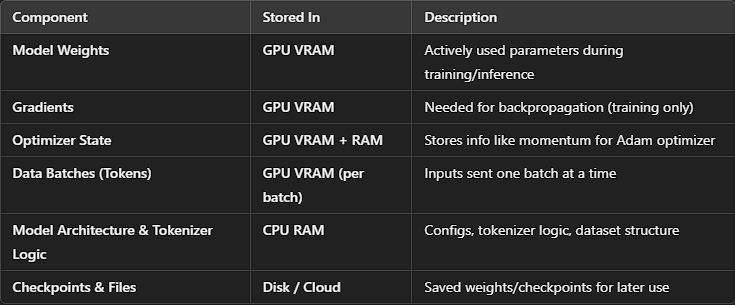